## MACHINE LEARNING NOTEBOOK

#### This notebook aims to :
1. **Predict Customer Conversion:** Build a binary classification model to accurately predict whether an online shopping session will result in revenue (a purchase) or not.

2. **Identify Key Behavioral Drivers:** Analyze feature importances to determine which browsing metrics  impact a user's decision to buy the most.

3. **Optimize Model Performance:** Evaluate the model using precision, recall, and F1-score to ensure it handles the imbalanced nature of the dataset effectively and minimizes false positives.

### Importing necessary libraries

In [10]:
# 1. Standard Data Manipulation
import pandas as pd
import numpy as np

# 2. Visualization (for evaluating our model later)
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Scikit-Learn Machine Learning Ecosystem
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import KFold, cross_val_score
# 4. Imbalanced-learn for SMOTE oversampling
from imblearn.over_sampling import SMOTE

### Loading the cleaned dataset 

In [11]:
# Read the CSV file
df = pd.read_csv('cleaned_online_shoppers_intention.csv')

# checking to ensure rows and columns loaded correctly
print(f"Dataset loaded successfully with {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset loaded successfully with 12330 rows and 18 columns.


## Data preprocessing

In [12]:
# 1. Isolate the target variable (Revenue) and convert True/False to 1/0
## True =1 and false = 0
y = df['Revenue'].astype(int)

# 2. Isolating the predictor features
X_raw = df.drop('Revenue', axis=1)

# 3. Convert categorical columns into numerical dummy variables
X = pd.get_dummies(X_raw, drop_first=True,dtype = int)

# 4. Preview the fully numerical features dataframe
X.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1


## Data Splitting and handling imbalance
 * From the data analysis, it shows the ratio of purchases to non purchases is 10422:1908 
 * This is about 0.85:0.15. The imbalance needs to be attended to


In [13]:
# Split the dataset 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20,       # 20% allocated to testing
    random_state=42,      # Ensures reproducible results every time you run it
    stratify=y            # Keeps the 15% vs 85% purchase ratio identical in both sets...
)

print(f"Training set size: {X_train.shape[0]} sessions")
print(f"Testing set size: {X_test.shape[0]} sessions")

# 2. Check class distribution BEFORE balancing
print(" Class Distribution BEFORE SMOTE (Training Set) ")
print(y_train.value_counts().rename({0: "No Purchase (0)", 1: "Purchase (1)"}).to_string())
print(f"Imbalance ratio: {y_train.value_counts()[0] / y_train.value_counts()[1]:.2f}:1")

Training set size: 9864 sessions
Testing set size: 2466 sessions
 Class Distribution BEFORE SMOTE (Training Set) 
Revenue
No Purchase (0)    8338
Purchase (1)       1526
Imbalance ratio: 5.46:1


In [14]:
# Apply SMOTE to balance the training set
# SMOTE is ONLY applied to the training data — never the test set
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Check class distribution AFTER balancing
print("Class Distribution AFTER SMOTE (Training Set)")
print(y_train_balanced.value_counts().rename({0: "No Purchase (0)", 1: "Purchase (1)"}).to_string())
print(f"New training set size: {X_train_balanced.shape[0]} sessions (balanced 50:50)")


Class Distribution AFTER SMOTE (Training Set)
Revenue
No Purchase (0)    8338
Purchase (1)       8338
New training set size: 16676 sessions (balanced 50:50)


### Model Training (Random Forest)

In [15]:
# 1. Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42, 
                                  class_weight="balanced", 
                                  n_estimators = 150, ## increasing number of trees from default 100 to 150 
                                  max_depth= 12) ## Limits tree growth to 12 preventing over fitting

# 2. Fit the model on the SMOTE-balanced training data
rf_model.fit(X_train_balanced, y_train_balanced)
print("Model trained successfully on SMOTE-balanced training data.")


 


Model trained successfully on SMOTE-balanced training data.


### Model Optimization 

In [ ]:
base_cv_scores = cross_val_score(rf_model, X, y, cv=5)

print(f"Baseline CV Scores: {base_cv_scores}")
print(f"Mean Baseline CV Score: {base_cv_scores.mean():.4f}")# cross validation scores before the actual cross validation with KFold

Baseline CV Scores: [0.92903487 0.89294404 0.86536902 0.8568532  0.85158151]
Mean Baseline CV Score: 0.8792


In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)# Performing 5-fold cross-validation

In [ ]:
cv_scores = cross_val_score(rf_model, X, y, cv=kf)
cv_mean = f"{cv_scores.mean():.4f}"

print("CV SCORES:", cv_scores)
print("CV MEAN:", cv_mean)# cross validation scores after performing KFold cross validation

CV SCORES: [0.88442822 0.89051095 0.8974047  0.88321168 0.89578264]
CV MEAN: 0.8903


### Model Evaluation

MODEL PERFORMANCE 
              precision    recall  f1-score   support

           0       0.95      0.92      0.94      2084
           1       0.63      0.73      0.68       382

    accuracy                           0.89      2466
   macro avg       0.79      0.82      0.81      2466
weighted avg       0.90      0.89      0.90      2466



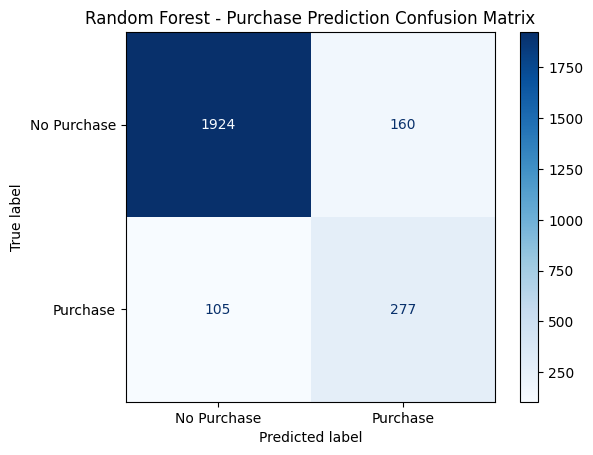

In [19]:
# 1. Generate predictions on the unseen test data
y_pred = rf_model.predict(X_test)

# 2. Print out the formal Classification Report (Precision, Recall, F1-Score)
print("MODEL PERFORMANCE ")
print(classification_report(y_test, y_pred))

# 3. Generate and plot a visual Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Purchase', 'Purchase'])
disp.plot(cmap='Blues')

plt.title("Random Forest - Purchase Prediction Confusion Matrix")
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_2468\3596798826.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')


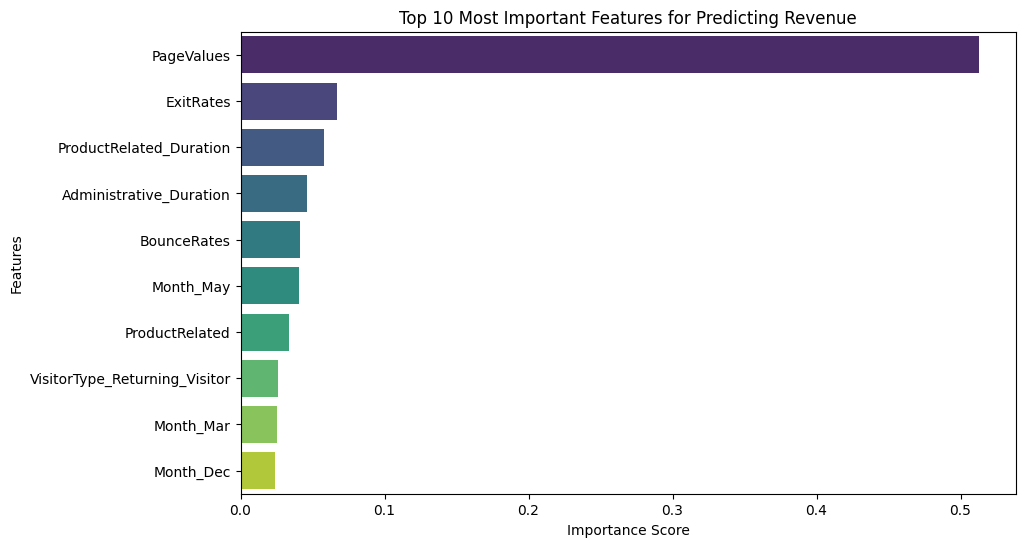

In [20]:
# Extract feature importances from your trained model
importances = rf_model.feature_importances_
feature_names = X.columns

# Create a clean DataFrame to display them
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False).head(10)

# Plot the top 10 features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Top 10 Most Important Features for Predicting Revenue')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

## OBSERVATION
 * Page values is the strongest feature affecting revenue
 * Most buyers are likely to spend more time on product related pages than administrative (log in /sign) in pages
 * The duration that a potential buyer interacts with on information (about, help) barely affects revenue


## Model Performance Analysis

The model achieved an overall accuracy of 88%, indicating strong general performance. However, given the class imbalance in the dataset (fewer buyers than non-buyers), accuracy alone is not a sufficient metric.

Focusing on the target class (buyers):

- **Recall (0.70)**: The model successfully identifies 70% of actual buyers. This is important from a business perspective, as it ensures that most potential customers are captured.

- **Precision (0.60)**: Out of all predicted buyers, 60% were actual buyers. This indicates that some non-buyers are incorrectly classified as buyers.

- **F1-score (0.65)**: The balance between precision and recall shows that the model performs reasonably well in identifying purchasing behavior.

The model prioritizes recall over precision, which is appropriate in this context. Missing a potential buyer represents a lost business opportunity, whereas incorrectly targeting a non-buyer has a lower cost.

Overall, the model demonstrates a strong ability to detect purchase intent, though there is room for improvement in reducing false positives.


* Before performing cross validation, the recall for buyers was 0.7 while precision was 0.6. 
* After performing cross validation without class balancing, the recall rose to 0.77 and precision fell to 0.56. With class balancing , recall was 0.73 while precision turned out to be 0.60
* cross validation score increased from 86.6 to 87.9 without class imbalance being handled

* After class imbalance was handled using smote, the cross validation score increased to 89.3